<img src="../holberton_logo.png" alt="logo" width="500"/>

# Time Series Forecasting

## What is time series forecasting?

Time series forecasting is a **method used to predict future values based on historical patterns and trends in a sequence of data points collected *over time***. 


It involves analyzing the **temporal relationships within the data** to make predictions about future values. 

The goal is to capture and model the underlying patterns and dynamics present in the data to generate accurate predictions.


- Time series forecasting is important because it helps in understanding and predicting future trends and patterns based on historical data.


- It is crucial for businesses to make informed decisions regarding **production planning, inventory management, and resource allocation**.


- Time series forecasting is used in **financial markets to predict stock prices, currency exchange rates, and commodity prices**, enabling investors and traders to make profitable decisions.


- **Weather forecasting** relies heavily on time series analysis to predict temperature, precipitation, and other meteorological variables, aiding in disaster preparedness and agricultural planning.



- **Demand forecasting in retail and e-commerce** industries helps optimize inventory levels, pricing strategies, and marketing campaigns based on projected customer demand.



- Time series forecasting is also used in **healthcare to predict disease outbreaks**, patient admissions, and resource allocation in hospitals.



- It plays a crucial role in **energy demand forecasting**, enabling utilities to plan and optimize power generation and distribution.



- **Transportation and logistics industries** utilize time series forecasting to predict traffic congestion, shipment volumes, and delivery times for efficient operations.



- **Social media sentiment analysis** uses time series forecasting to predict public opinion and trends, aiding in marketing and brand management strategies.


- Time series forecasting is essential in **telecommunications for network capacity planning** and predicting call volumes, ensuring smooth communication services.


## What is a stationary process?

A **stationary process**, also known as a stationary time series, is a **statistical model where the properties of the data do not change over time**. 


In a stationary process, **the mean, variance, and autocovariance structure remain constant across different time periods**. 


This implies that the statistical properties of the process, such as the *distribution of the data and the relationship between data points, are time-invariant*. 


A typical example of a stationary process is white noise, which consists of uncorrelated random variables with a constant mean and variance. In white noise, each data point is independent of others and has the same probability distribution, making it stationary.


Below is an example

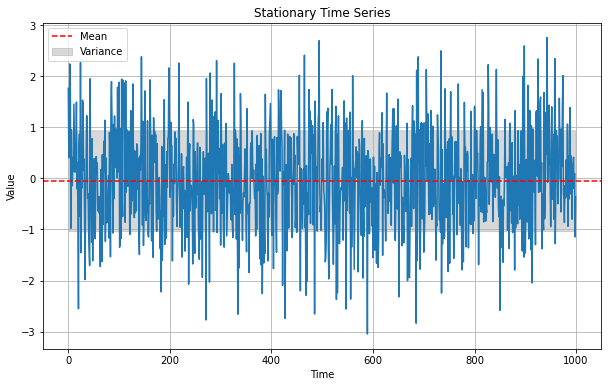

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random data for a stationary process
np.random.seed(0)
data = np.random.normal(loc=0, scale=1, size=1000)

# Calculate mean and variance
mean = np.mean(data)
variance = np.var(data)

# Plot the time series data
plt.figure(figsize=(10, 6))
plt.plot(data)
plt.axhline(mean, color='red', linestyle='--', label='Mean')
plt.fill_between(range(len(data)), mean - np.sqrt(variance), mean + np.sqrt(variance),
                 alpha=0.3, color='gray', label='Variance')

plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Stationary Time Series')
plt.legend()
plt.grid(True)
plt.show()


## What is a sliding window?

A **sliding window**, also known as a rolling window, is a technique used in time series analysis and signal processing to **analyze data by moving a fixed-size window along the sequence of data points**.


*The window slides through the data sequentially, with each iteration capturing a subset of consecutive data points. The window size determines the number of data points considered at each step.*


By applying operations or computations within the sliding window, such as calculating averages, sums, or other statistical measures, it allows for localized analysis and extraction of patterns or insights. 


The sliding window technique is commonly used for smoothing data, detecting anomalies, feature extraction, and implementing time series forecasting models that utilize a fixed-size history to make predictions.




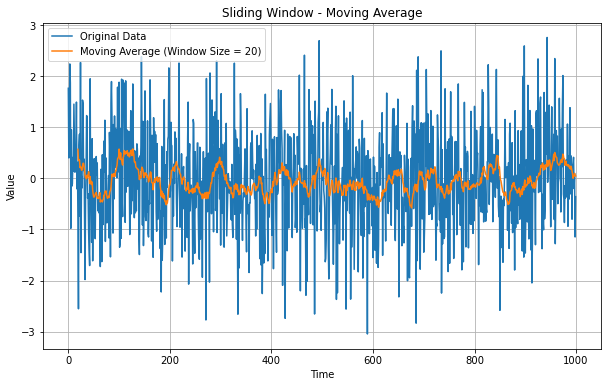

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random time series data
np.random.seed(0)
data = np.random.randn(1000)  # Random data points

# Define sliding window size and calculate moving average
window_size = 20
moving_average = np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Plot the original data and moving average
plt.figure(figsize=(10, 6))
plt.plot(data, label='Original Data')
plt.plot(np.arange(window_size-1, len(data)), moving_average, label=f'Moving Average (Window Size = {window_size})')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Sliding Window - Moving Average')
plt.legend()
plt.grid(True)
plt.show()


### Note on the window size parameter

The window size parameter determines the number of data points considered at each step when applying the sliding window technique. 


It specifies the length or size of the window that slides along the time series data. A larger window size includes more data points in the analysis, providing a broader context and potentially capturing longer-term patterns. 


On the other hand, a smaller window size focuses on a smaller subset of consecutive data points, offering a more localized analysis and potentially capturing shorter-term fluctuations. 


The choice of the window size depends on the specific characteristics and objectives of the analysis, striking a balance between capturing relevant patterns and preserving the level of detail in the data.

## How to preprocess time series data

1. **Handling missing values**: Determine the appropriate method to handle missing values, such as interpolation or forward/backward filling.



2. **Resampling**: If the data is unevenly spaced, resample it to a fixed frequency using techniques like upsampling or downsampling.



3. **Removing outliers**: Identify and handle any outliers or anomalies in the data that may impact the analysis or model performance.


4. **Normalization/Scaling**: Normalize or scale the data to a common range to mitigate the influence of different scales and enable fair comparisons between variables.



5. **Detrending**: Remove any trend or seasonality present in the data, such as by differencing or using techniques like moving averages.



6. **Feature engineering**: Extract relevant features from the time series, such as lagged variables, rolling statistics, or Fourier transforms, to capture important patterns.



7. **Train-test split**: Divide the data into training and test sets for model evaluation, ensuring that the temporal order is maintained.


By performing these preprocessing steps, the time series data is cleaned, standardized, and made ready for analysis, forecasting, or modeling tasks.

## Analyzing BitCoin Data

### Read the dataset

In [3]:
import pandas as pd

# Read the dataset from CSV file
df = pd.read_csv('coinbaseUSD_1-min_data_2014-12-01_to_2019-01-09.csv')

# Display the first few rows of the dataset
print("\n\nDataset example (first 5 rows)")
print(df.head())

# Check the dimensions of the dataset (number of rows, number of columns)
print("\n\nDimensions of the dataset")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Check the data types of each column
print("\n\nData Types")
print(df.dtypes)

# Get summary statistics of the dataset
print("\n\nSummary Statistics")
print(df.describe())

# Calculate the missing values in each column
print("\n\nNull Values")
print(df.isnull().sum())




Dataset example (first 5 rows)
    Timestamp   Open   High    Low  Close  Volume_(BTC)  Volume_(Currency)  \
0  1417411980  300.0  300.0  300.0  300.0          0.01                3.0   
1  1417412040    NaN    NaN    NaN    NaN           NaN                NaN   
2  1417412100    NaN    NaN    NaN    NaN           NaN                NaN   
3  1417412160    NaN    NaN    NaN    NaN           NaN                NaN   
4  1417412220    NaN    NaN    NaN    NaN           NaN                NaN   

   Weighted_Price  
0           300.0  
1             NaN  
2             NaN  
3             NaN  
4             NaN  


Dimensions of the dataset
Number of rows: 2099760
Number of columns: 8


Data Types
Timestamp              int64
Open                 float64
High                 float64
Low                  float64
Close                float64
Volume_(BTC)         float64
Volume_(Currency)    float64
Weighted_Price       float64
dtype: object


Summary Statistics
          Timestamp      

### Visualizing the dataset

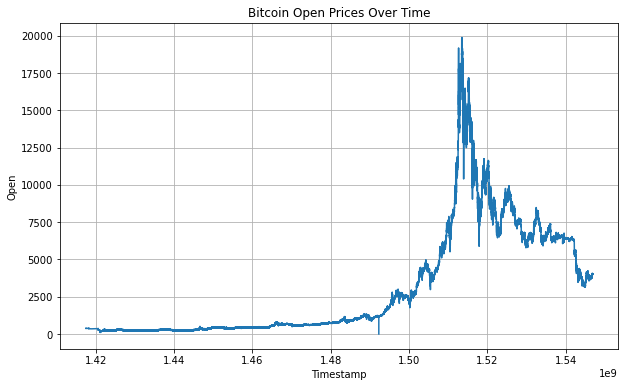

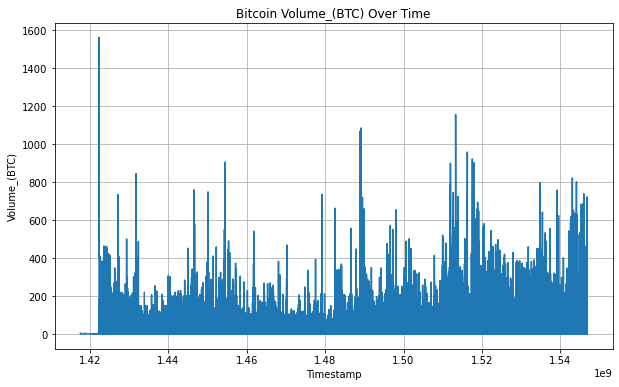

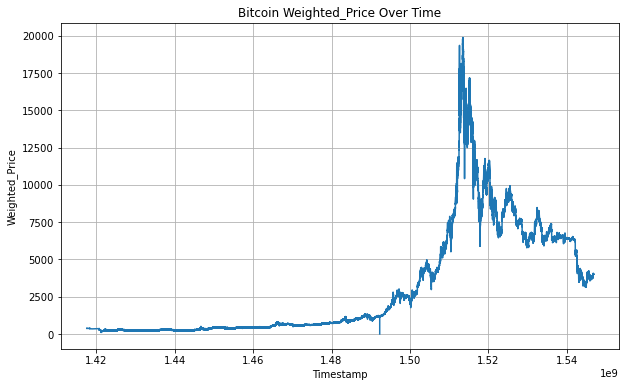

In [4]:
import matplotlib.pyplot as plt

# Visualize the 'Open' column
plt.figure(figsize=(10, 6))
plt.plot(df['Timestamp'], df['Open'])
plt.xlabel('Timestamp')
plt.ylabel('Open')
plt.title('Bitcoin Open Prices Over Time')
plt.grid(True)
plt.show()

# Visualize the 'Volume_(BTC)' column
plt.figure(figsize=(10, 6))
plt.plot(df['Timestamp'], df['Volume_(BTC)'])
plt.xlabel('Timestamp')
plt.ylabel('Volume_(BTC)')
plt.title('Bitcoin Volume_(BTC) Over Time')
plt.grid(True)
plt.show()

# Visualize the 'Weighted_Price' column
plt.figure(figsize=(10, 6))
plt.plot(df['Timestamp'], df['Weighted_Price'])
plt.xlabel('Timestamp')
plt.ylabel('Weighted_Price')
plt.title('Bitcoin Weighted_Price Over Time')
plt.grid(True)

## Preprocessing

### Check, Visualize, and Remove Missing Value

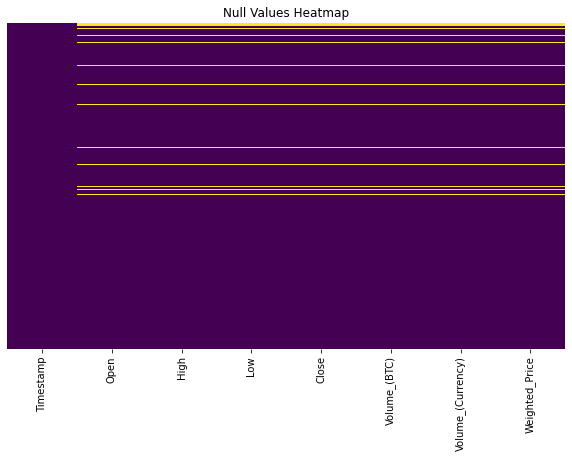

In [6]:
import seaborn as sns

# Generate a heatmap of null values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Null Values Heatmap')
plt.show()

In [7]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Remove rows with missing values
df = df.dropna()

# Verify if missing values have been removed
print("Missing values after removal:")
print(df.isnull().sum())

Missing values:
Timestamp                 0
Open                 109069
High                 109069
Low                  109069
Close                109069
Volume_(BTC)         109069
Volume_(Currency)    109069
Weighted_Price       109069
dtype: int64
Missing values after removal:
Timestamp            0
Open                 0
High                 0
Low                  0
Close                0
Volume_(BTC)         0
Volume_(Currency)    0
Weighted_Price       0
dtype: int64


### Split the Data 

In [8]:
from sklearn.model_selection import train_test_split

# Split the data into training, validation, and testing sets
train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

# Split the data into training and remaining data
train_data, remaining_data = train_test_split(df, train_size=train_ratio, random_state=42)

# Split the remaining data into validation and testing
val_data, test_data = train_test_split(remaining_data, test_size=test_ratio/(test_ratio + val_ratio), random_state=42)

# Verify the sizes of the split datasets
print("Training data size:", train_data.shape)
print("Validation data size:", val_data.shape)
print("Testing data size:", test_data.shape)

Training data size: (1393483, 8)
Validation data size: (398138, 8)
Testing data size: (199070, 8)


### Data Split Distribution

Text(0.5, 1.0, 'Data Split Distribution')

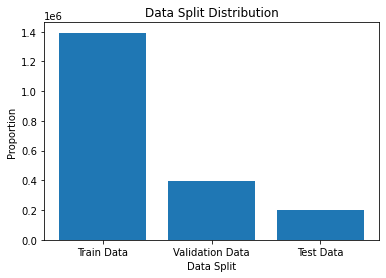

In [9]:
# Create a bar plot
labels = ['Train Data', 'Validation Data', 'Test Data']
values = [train_data.shape[0], val_data.shape[0], test_data.shape[0]]

plt.bar(labels, values)
plt.xlabel('Data Split')
plt.ylabel('Proportion')
plt.title('Data Split Distribution')

### Normalize Based on Training Data

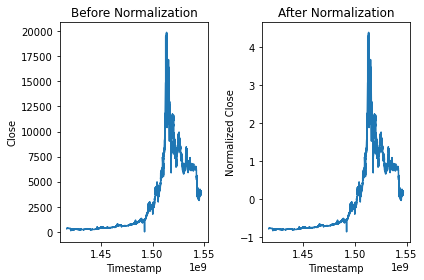

In [14]:
# Plot Timestamp against Close before normalization
plt.subplot(1, 2, 1)
plt.plot(df['Timestamp'], df['Close'])
plt.xlabel('Timestamp')
plt.ylabel('Close')
plt.title('Before Normalization')

# Plot Timestamp against Close after normalization
train_mean = train_data['Close'].mean()
train_std = train_data['Close'].std()
plt.subplot(1, 2, 2)
plt.plot(df['Timestamp'], (df['Close'] - train_mean) / train_std)
plt.xlabel('Timestamp')
plt.ylabel('Normalized Close')
plt.title('After Normalization')

# Adjust subplot spacing
plt.tight_layout()

In [15]:
# Calculate mean and standard deviation of the training data
train_mean = train_data.mean()
train_std = train_data.std()

# Normalize the training data
train_data = (train_data - train_mean) / train_std

# Normalize the validation data using the training data mean and std
val_data = (val_data - train_mean) / train_std

# Normalize the testing data using the training data mean and std
test_data = (test_data - train_mean) / train_std

### Visualize the Preprocessed data

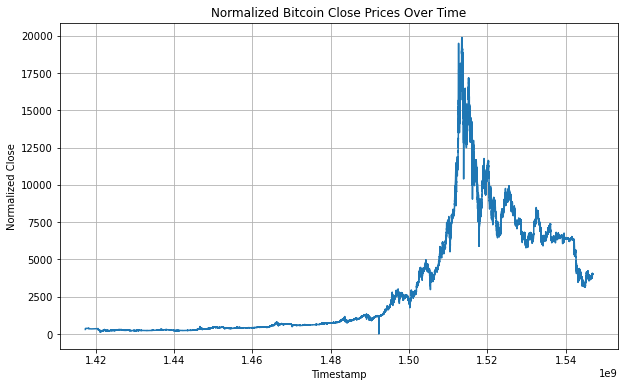

In [16]:
# Plot the normalized 'Close' column against 'Timestamp'
plt.figure(figsize=(10, 6))
plt.plot(df['Timestamp'], df['Close'])
plt.xlabel('Timestamp')
plt.ylabel('Normalized Close')
plt.title('Normalized Bitcoin Close Prices Over Time')
plt.grid(True)
plt.show()

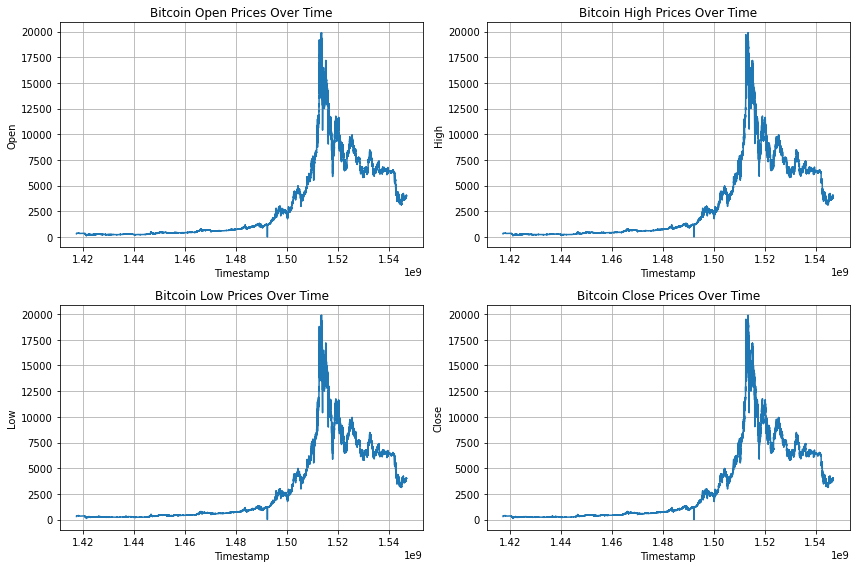

In [17]:
# Select the four columns to visualize
columns = ['Open', 'High', 'Low', 'Close']

# Create a subplot grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# Iterate through the columns and plot against 'Timestamp'
for i, ax in enumerate(axes.flat):
    ax.plot(df['Timestamp'], df[columns[i]])
    ax.set_xlabel('Timestamp')
    ax.set_ylabel(columns[i])
    ax.set_title(f'Bitcoin {columns[i]} Prices Over Time')
    ax.grid(True)

# Adjust the layout and spacing between subplots
plt.tight_layout()

# Display the subplot grid
plt.show()
